# 00 · TabPFN-3.5 as a weekly-refit trade filter for my live strategy

**This notebook uses my live strategy's real signals.** Their 32 features are private and not in this repo; the file
`data/strategy/rolling_predictions.parquet` holds each model's probability, its decision and the outcome for every signal.

The rule (PREREG.md, amendment 3), fixed before the run:
- every Monday, refit on the previous 12 weeks of signals (TabPFN-3.5 untuned; logistic regression and LightGBM at defaults);
- take a signal only if 100 × p − entry price − fee > 0;
- stake 15% of the account, or half the Kelly stake from p capped at 15%.

Every other notebook uses public data and generic indicators.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tabtrader import plots
plots.style()
pd.set_option("display.width", 140, "display.max_columns", 30)

In [2]:
from tabtrader import bankroll
from tabtrader.report_data import ROLL_MODELS
d = pd.read_parquet(ROOT / "data" / "strategy" / "rolling_predictions.parquet")
meta = json.loads((ROOT / "data" / "strategy" / "rolling_meta.json").read_text())
print(meta["first_week"], "to", meta["last_signal"], "·", meta["weeks"], "weeks ·", meta["signals"], "signals")
d.head()

2026-05-11 to 2026-10-06 · 22 weeks · 2874 signals


,day,week,px,won,net_c_exits,split,p__TabPFN-3.5,take__TabPFN-3.5,frac__TabPFN-3.5 + Kelly,take__TabPFN-3.5 + Kelly,take__TabPFN-3.5 · calibrated,p__Logistic regression,take__Logistic regression,frac__Logistic regression + Kelly,take__Logistic regression + Kelly,take__Logistic regression · calibrated,p__LightGBM,take__LightGBM,frac__LightGBM + Kelly,take__LightGBM + Kelly,take__LightGBM · calibrated,take__Live gate,take__Every signal,seq
0,2026-05-11,0,78.0,1,20.0,rolling,0.69418,False,0.0000,False,False,0.60718,False,0.0000,False,False,0.76976,False,0.0000,False,False,False,True,0
1,2026-05-11,0,81.0,0,-74.0,rolling,0.76269,False,0.0000,False,False,0.85852,True,0.1053,True,True,0.85828,True,0.1046,True,True,True,True,1
2,2026-05-11,0,34.0,1,64.0,rolling,0.40325,True,0.0369,True,True,0.38222,True,0.0206,True,True,0.10729,False,0.0000,False,False,False,True,2
3,2026-05-11,0,87.0,1,12.0,rolling,0.82104,False,0.0000,False,False,0.86828,False,0.0000,False,False,0.86034,False,0.0000,False,False,False,True,3
4,2026-05-11,0,56.0,0,-58.0,rolling,0.58451,True,0.0086,True,True,0.52158,False,0.0000,False,False,0.74747,True,0.1500,True,True,False,True,4


### Account value from $100

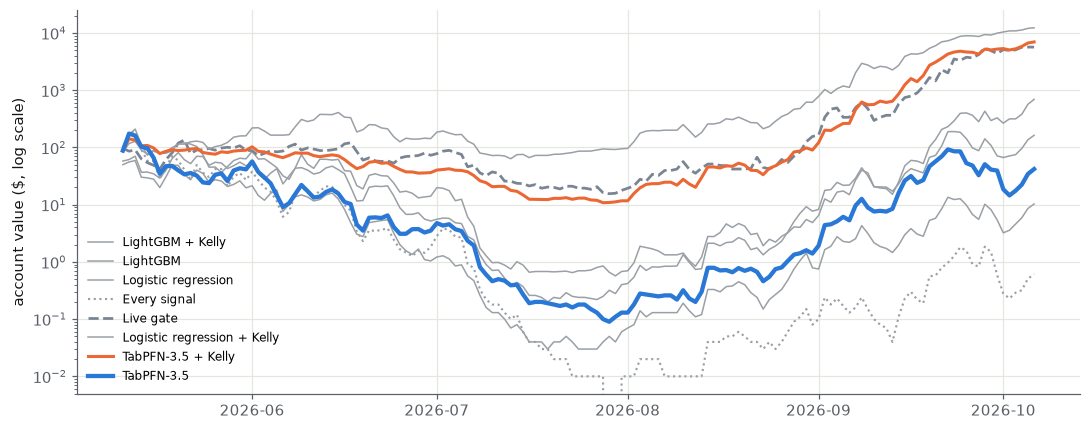

In [3]:
res = bankroll.run_models(d, ROLL_MODELS)
fig, ax = plt.subplots(figsize=(10, 4))
for m in ROLL_MODELS[::-1]:
    c = pd.DataFrame(res[m]["curve"], columns=["day", "v"]); c["day"] = pd.to_datetime(c["day"])
    style = {"TabPFN-3.5": (plots.TABPFN, 2.8, "-"), "TabPFN-3.5 + Kelly": (plots.FAST, 2, "-"),
             "Live gate": ("#7a8594", 1.8, "--"), "Every signal": (plots.CLASSIC, 1.4, ":")}.get(m, (plots.CLASSIC, 1, "-"))
    ax.plot(c.day, c.v, color=style[0], lw=style[1], ls=style[2], label=m)
ax.set_yscale("log"); ax.set_ylabel("account value ($, log scale)"); ax.legend(fontsize=8); plt.tight_layout()

### Tear sheet

In [4]:
cols = ["final", "sharpe", "sortino", "max_dd_pct", "trades", "win_rate", "c_per_ct", "weeks_up"]
pd.DataFrame({m: {k: r[k] for k in cols} for m, r in res.items()}).T.sort_values("final", ascending=False)

,final,sharpe,sortino,max_dd_pct,trades,win_rate,c_per_ct,weeks_up
Logistic regression + Kelly,12356.55,5.25,10.5,-84.5,1660,0.722,1.97,17/23
TabPFN-3.5 + Kelly,6987.03,4.62,11.74,-92.4,1583,0.702,1.68,14/23
Live gate,5683.15,4.25,8.7,-88.5,1591,0.79,1.87,14/23
Logistic regression,692.99,3.41,7.02,-99.7,1660,0.722,1.97,12/23
LightGBM + Kelly,163.21,2.7,5.46,-99.8,2260,0.723,1.04,12/23
TabPFN-3.5,41.94,2.29,4.59,-99.9,1583,0.702,1.68,10/23
LightGBM,10.28,1.93,3.7,-100.0,2260,0.723,1.04,11/23
Every signal,0.61,2.04,4.48,-100.0,2874,0.7,0.83,10/23


### Month by month (¢ per contract)

In [5]:
d["month"] = d.day.str[:7]
rows = {}
for mo, g in d.groupby("month"):
    rows[mo] = {m: (round(g.net_c_exits[g[f"take__{m}"]].mean(), 2), int(g[f"take__{m}"].sum()))
                for m in ["Every signal", "TabPFN-3.5", "Live gate", "Logistic regression", "LightGBM"]}
pd.DataFrame(rows).T

,Every signal,TabPFN-3.5,Live gate,Logistic regression,LightGBM
2026-05,"(0.58, 514)","(-0.01, 181)","(0.67, 291)","(0.71, 220)","(-0.08, 387)"
2026-06,"(-0.4, 648)","(-1.07, 353)","(0.17, 317)","(-0.26, 427)","(-1.2, 522)"
2026-07,"(-4.65, 382)","(-5.6, 173)","(-2.71, 214)","(-4.82, 185)","(-2.87, 280)"
2026-08,"(3.61, 471)","(4.36, 336)","(4.37, 278)","(3.55, 343)","(3.97, 379)"
2026-09,"(2.71, 744)","(4.62, 470)","(4.08, 449)","(5.64, 431)","(2.9, 596)"
2026-10,"(3.46, 115)","(5.29, 70)","(6.14, 42)","(8.65, 54)","(6.01, 96)"


### Real fills: my live trades since 2026-09-12, with and without TabPFN's veto

377 live trades; TabPFN keeps 166: kept +6.90 ¢/ct, skipped +0.35 ¢/ct


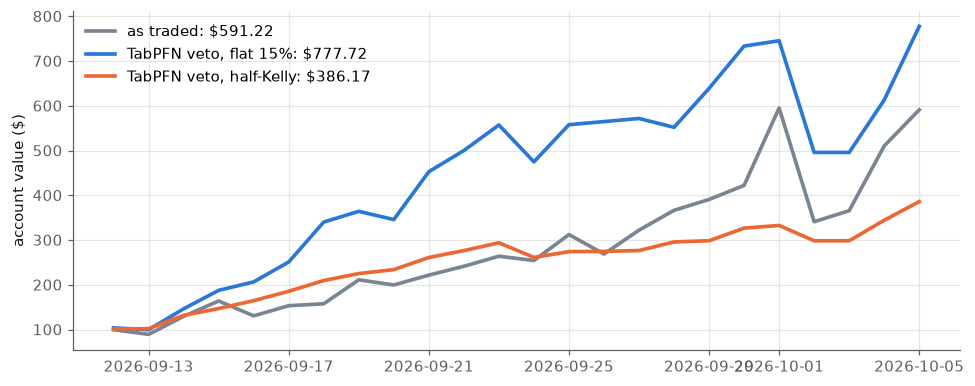

In [6]:
lt = pd.read_parquet(ROOT / "data" / "strategy" / "rolling_live_trades.parquet")
days = pd.date_range(lt.day.min(), lt.day.max(), freq="D")
fig, ax = plt.subplots(figsize=(9, 3.6))
for lab, take, frac, col in [("as traded", np.ones(len(lt), bool), 0.15, "#7a8594"),
                             ("TabPFN veto, flat 15%", lt.tabpfn_keeps.values, 0.15, plots.TABPFN),
                             ("TabPFN veto, half-Kelly", lt.tabpfn_keeps.values, lt.frac_kelly.values, plots.FAST)]:
    eq = bankroll.daily_equity(lt.day, lt.real_net_c.values, lt.px_fill.values, take, days, risk=frac)
    ax.plot(eq.index, eq.values, color=col, lw=2.4, label=f"{lab}: ${eq.iloc[-1]:,.2f}")
ax.set_ylabel("account value ($)"); ax.legend(); plt.tight_layout()
k = lt.tabpfn_keeps
print(f"{len(lt)} live trades; TabPFN keeps {k.sum()}: kept {lt.real_net_c[k].mean():+.2f} ¢/ct, skipped {lt.real_net_c[~k].mean():+.2f} ¢/ct")